In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import os

print(os.listdir())

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")

drugs = [
    "Paracetamol", "Amoxicillin", "Azithromycin", "Ibuprofen",
    "Cetirizine", "Omeprazole", "Metformin", "Amlodipine",
    "Atorvastatin", "Pantoprazole"
]

categories = [
    "Branded", "Generic", "Branded", "Generic",
    "Generic", "Branded", "Generic", "Branded",
    "Branded", "Generic"
]

data = []

for i in range(1000):
    drug_index = np.random.randint(0, len(drugs))
    quantity = np.random.randint(1, 21)
    price = round(np.random.uniform(2, 50), 2)

    data.append([
        np.random.choice(dates),
        drugs[drug_index],
        categories[drug_index],
        quantity,
        price,
        round(quantity * price, 2)
    ])

df = pd.DataFrame(
    data,
    columns=[
        "Date",
        "Drug Name",
        "Category",
        "Quantity",
        "Price (USD)",
        "Sales (USD)"
    ]
)

df.head()

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "Date": pd.date_range("2025-01-01", periods=1000),
    "Drug Name": np.random.choice(
        ["Paracetamol", "Amoxicillin", "Azithromycin", "Ibuprofen", "Cetirizine"],
        1000
    ),
    "Category": np.random.choice(["Branded", "Generic"], 1000),
    "Quantity": np.random.randint(1, 21, 1000),
    "Price (USD)": np.round(np.random.uniform(2, 50, 1000), 2)
})

df["Sales (USD)"] = df["Quantity"] * df["Price (USD)"]

df.head()

,Date,Drug Name,Category,Quantity,Price (USD),Sales (USD)
0,2025-01-01,Ibuprofen,Generic,12,32.46,389.52
1,2025-01-02,Cetirizine,Generic,17,40.30,685.10
2,2025-01-03,Azithromycin,Generic,8,21.01,168.08
3,2025-01-04,Cetirizine,Generic,11,45.92,505.12
4,2025-01-05,Cetirizine,Generic,3,27.59,82.77


In [ ]:
df.shape

(1000, 6)

In [ ]:
df.isnull().sum()

,0
Date,0
Drug Name,0
Category,0
Quantity,0
Price (USD),0
Sales (USD),0


In [ ]:
total_sales = df["Sales (USD)"].sum()
total_sales

np.float64(274176.97)

In [ ]:
total_quantity = df["Quantity"].sum()
total_quantity

np.int64(10455)

In [ ]:
total_orders = len(df)
total_orders

1000

In [ ]:
average_order_value = total_sales / total_orders
average_order_value

np.float64(274.17697)

In [ ]:
top_drugs = df.groupby("Drug Name")["Sales (USD)"].sum().sort_values(ascending=False)

top_drugs.head(5)

,Sales (USD)
Drug Name,
Cetirizine,60738.65
Paracetamol,56923.59
Ibuprofen,55310.03
Azithromycin,53216.86
Amoxicillin,47987.84


In [ ]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Sales (USD)"].sum()

monthly_sales

,Sales (USD)
Date,
2025-01,9907.38
2025-02,8934.47
2025-03,8467.11
2025-04,7296.75
2025-05,8757.67
2025-06,9565.61
2025-07,6348.71
2025-08,7229.43
2025-09,6397.36


In [ ]:
df = df[df["Date"].dt.year == 2025].copy()

df.shape

(365, 6)

In [ ]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Sales (USD)"].sum()

monthly_sales

,Sales (USD)
Date,
2025-01,9907.38
2025-02,8934.47
2025-03,8467.11
2025-04,7296.75
2025-05,8757.67
2025-06,9565.61
2025-07,6348.71
2025-08,7229.43
2025-09,6397.36


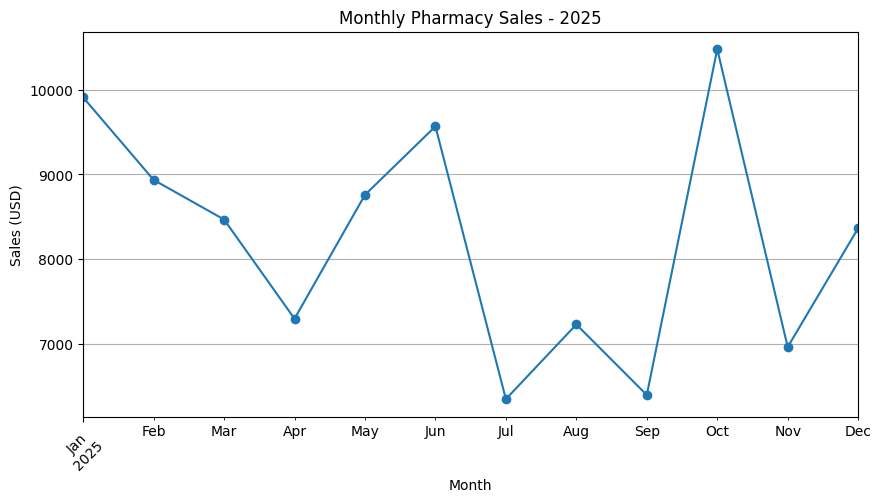

In [ ]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Pharmacy Sales - 2025")
plt.xlabel("Month")
plt.ylabel("Sales (USD)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
monthly_growth = monthly_sales.pct_change() * 100

monthly_growth

,Sales (USD)
Date,
2025-01,NaN
2025-02,-9.820053
2025-03,-5.230976
2025-04,-13.822426
2025-05,20.021516
2025-06,9.225513
2025-07,-33.629847
2025-08,13.872424
2025-09,-11.509483


In [ ]:
category_sales = df.groupby("Category")["Sales (USD)"].sum()

category_sales

,Sales (USD)
Category,
Branded,51774.63
Generic,46934.09


In [ ]:
category_quantity = df.groupby("Category")["Quantity"].sum()

category_quantity

,Quantity
Category,
Branded,1953
Generic,1879


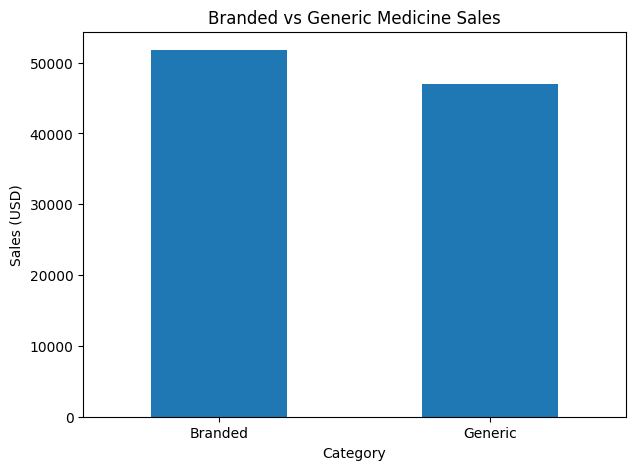

In [ ]:
category_sales.plot(kind="bar", figsize=(7,5))

plt.title("Branded vs Generic Medicine Sales")
plt.xlabel("Category")
plt.ylabel("Sales (USD)")
plt.xticks(rotation=0)
plt.show()

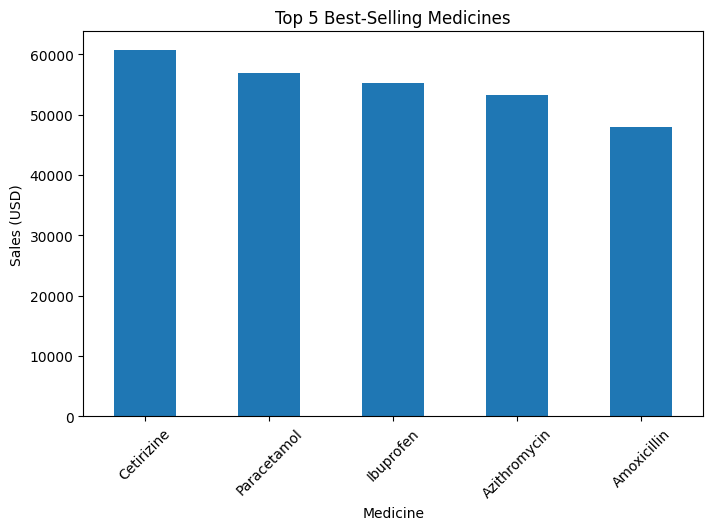

In [ ]:
top_5 = top_drugs.head(5)

top_5.plot(kind="bar", figsize=(8,5))

plt.title("Top 5 Best-Selling Medicines")
plt.xlabel("Medicine")
plt.ylabel("Sales (USD)")
plt.xticks(rotation=45)
plt.show()

## Task 3: Pharmacy Sales Analysis – Key Insights

- Total sales generated in 2025 were approximately USD 98,708.72.
- A total of 3,832 medicine units were sold across 365 orders.
- The average order value was approximately USD 270.43.
- Cetirizine recorded the highest sales among the medicines analyzed.
- October showed the highest monthly sales growth compared with September.
- July experienced the largest monthly decline in sales compared with June.
- Branded medicines generated higher sales and quantity than generic medicines in this dataset.
- The analysis helps identify medicine sales trends, monthly performance, and differences between branded and generic products.


In [5]:
import pandas as pd

df = pd.read_csv('/content/Synthetic_Medical_Dataset_v2.csv')

df.head()

,Patient_ID,Age,Gender,Blood_Group,Weight_kg,Has_Fever,Has_Cough,Has_Fatigue,Has_Pain,Has_Hypertension,...,Duration_2,Instructions_2,Medicine_3,Dosage_3,Frequency_3,Duration_3,Instructions_3,Personalized_Health_Tips,Polypharmacy_Risk,Polypharmacy_Recommendation
0,1,61,Male,B+,92.9,0,0,0,1,0,...,As needed,Apply to affected joint.,NaN,NaN,NaN,NaN,NaN,"Maintain healthy weight, low-impact exercise (...",Low,Monitor liver function with high-dose acetamin...
1,2,45,Male,AB+,82.7,0,0,1,0,1,...,Short-term only,"For panic attacks, use sparingly due to depend...",NaN,NaN,NaN,NaN,NaN,"Cognitive behavioral therapy (CBT), stress man...",Medium,Monitor for side effects of SSRI. Caution with...
2,3,23,Male,B+,64.0,0,0,1,1,0,...,As needed,Apply to affected joint.,NaN,NaN,NaN,NaN,NaN,"Maintain healthy weight, low-impact exercise (...",Low,Monitor liver function with high-dose acetamin...
3,4,49,Female,B-,77.1,1,0,0,1,0,...,As needed,For fever/pain relief.,NaN,NaN,NaN,NaN,NaN,"Get annual flu shot, rest, fluids, avoid contact.",Medium,"Review potential interactions, especially Osel..."
4,5,44,Female,O+,99.3,0,0,1,0,0,...,Short-term only,"For panic attacks, use sparingly due to depend...",NaN,NaN,NaN,NaN,NaN,"Cognitive behavioral therapy (CBT), stress man...",Medium,Monitor for side effects of SSRI. Caution with...


In [6]:
df.columns.tolist()

['Patient_ID',
 'Age',
 'Gender',
 'Blood_Group',
 'Weight_kg',
 'Has_Fever',
 'Has_Cough',
 'Has_Fatigue',
 'Has_Pain',
 'Has_Hypertension',
 'Has_Diabetes',
 'Temperature_C',
 'Heart_Rate',
 'BP_Systolic',
 'WBC_Count',
 'Glucose_Level',
 'Predicted_Disease',
 'Disease_Causes',
 'Medicine_1',
 'Dosage_1',
 'Frequency_1',
 'Duration_1',
 'Instructions_1',
 'Medicine_2',
 'Dosage_2',
 'Frequency_2',
 'Duration_2',
 'Instructions_2',
 'Medicine_3',
 'Dosage_3',
 'Frequency_3',
 'Duration_3',
 'Instructions_3',
 'Personalized_Health_Tips',
 'Polypharmacy_Risk',
 'Polypharmacy_Recommendation']

In [7]:
df[['Medicine_1', 'Medicine_2', 'Medicine_3']].head(10)

,Medicine_1,Medicine_2,Medicine_3
0,Acetaminophen,Topical NSAID Cream,NaN
1,Sertraline,Alprazolam,NaN
2,Acetaminophen,Topical NSAID Cream,NaN
3,Oseltamivir,Acetaminophen,NaN
4,Sertraline,Alprazolam,NaN
5,Oseltamivir,Acetaminophen,NaN
6,Ibuprofen,Decongestant Spray,NaN
7,Metformin,Atorvastatin,Lisinopril
8,Oseltamivir,Acetaminophen,NaN
9,Acetaminophen,Topical NSAID Cream,NaN


In [8]:
df[['Has_Fever', 'Has_Cough', 'Has_Fatigue', 'Has_Pain']].head(10)

,Has_Fever,Has_Cough,Has_Fatigue,Has_Pain
0,0,0,0,1
1,0,0,1,0
2,0,0,1,1
3,1,0,0,1
4,0,0,1,0
5,1,1,1,1
6,0,1,0,0
7,0,1,0,0
8,1,1,1,1
9,0,0,0,1


In [9]:
df['Predicted_Disease'].value_counts()

,count
Predicted_Disease,
Anxiety Disorder,1222
Diabetes Type 2,1195
Urinary Tract Infection,1195
Influenza,1182
Bacterial Pneumonia,1179
GERD,1174
Hypothyroidism,1143
Hypertension,1143
Asthma Exacerbation,1138


In [10]:
medicine_counts = pd.concat([
    df['Medicine_1'],
    df['Medicine_2'],
    df['Medicine_3']
]).dropna().value_counts()

medicine_counts

,count
Acetaminophen,3493
Lisinopril,2338
Albuterol Inhaler,2317
Alprazolam,1222
Sertraline,1222
Metformin,1195
Phenazopyridine,1195
Atorvastatin,1195
Trimethoprim/Sulfamethoxazole,1195
Oseltamivir,1182


In [11]:
df['Possible_ADR'] = df[['Has_Fever', 'Has_Cough', 'Has_Fatigue', 'Has_Pain']].sum(axis=1)

df['Possible_ADR'].value_counts().sort_index()

,count
Possible_ADR,
0,2418
1,5298
2,4167
3,1931
4,1186


In [12]:
symptom_counts = df[['Has_Fever', 'Has_Cough', 'Has_Fatigue', 'Has_Pain']].sum()

symptom_counts

,0
Has_Fever,3784
Has_Cough,4998
Has_Fatigue,7597
Has_Pain,7790


In [13]:
medicine_columns = ['Medicine_1', 'Medicine_2', 'Medicine_3']

medicine_long = df[medicine_columns].melt(
    value_name='Medicine'
).dropna()

medicine_long.head()

,variable,Medicine
0,Medicine_1,Acetaminophen
1,Medicine_1,Sertraline
2,Medicine_1,Acetaminophen
3,Medicine_1,Oseltamivir
4,Medicine_1,Sertraline


In [14]:
medicine_long['Medicine'].value_counts()

,count
Medicine,
Acetaminophen,3493
Lisinopril,2338
Albuterol Inhaler,2317
Alprazolam,1222
Sertraline,1222
Metformin,1195
Phenazopyridine,1195
Atorvastatin,1195
Trimethoprim/Sulfamethoxazole,1195


In [15]:
medicine_adr = medicine_long.merge(
    df[['Patient_ID', 'Possible_ADR']],
    left_index=True,
    right_index=True
)

medicine_adr.head()

,variable,Medicine,Patient_ID,Possible_ADR
0,Medicine_1,Acetaminophen,1,1
1,Medicine_1,Sertraline,2,1
2,Medicine_1,Acetaminophen,3,2
3,Medicine_1,Oseltamivir,4,2
4,Medicine_1,Sertraline,5,1


In [16]:
medicine_adr_summary = medicine_adr.groupby('Medicine').agg(
    Total_Exposures=('Patient_ID', 'count'),
    Possible_ADR_Signals=('Possible_ADR', lambda x: (x > 0).sum())
)

medicine_adr_summary['ADR_Signal_Rate_%'] = (
    medicine_adr_summary['Possible_ADR_Signals']
    / medicine_adr_summary['Total_Exposures']
    * 100
)

medicine_adr_summary.sort_values(
    'ADR_Signal_Rate_%',
    ascending=False
)

,Total_Exposures,Possible_ADR_Signals,ADR_Signal_Rate_%
Medicine,,,
Amoxicillin,1179,1179,100.000000
Oseltamivir,1182,1182,100.000000
Acetaminophen,1132,1099,97.084806
Sumatriptan,1092,1058,96.886447
Ibuprofen,1121,1083,96.610169
Trimethoprim/Sulfamethoxazole,1195,1145,95.815900
Levothyroxine,1143,1085,94.925634
Albuterol Inhaler,1138,1075,94.463972
Omeprazole,1174,1091,92.930153


In [17]:
medicine_long = df.melt(
    id_vars='Patient_ID',
    value_vars=['Medicine_1', 'Medicine_2', 'Medicine_3'],
    value_name='Medicine'
).dropna(subset=['Medicine'])

medicine_long.head()

,Patient_ID,variable,Medicine
0,1,Medicine_1,Acetaminophen
1,2,Medicine_1,Sertraline
2,3,Medicine_1,Acetaminophen
3,4,Medicine_1,Oseltamivir
4,5,Medicine_1,Sertraline


In [18]:
medicine_counts = medicine_long['Medicine'].value_counts()

medicine_counts

,count
Medicine,
Acetaminophen,3493
Lisinopril,2338
Albuterol Inhaler,2317
Alprazolam,1222
Sertraline,1222
Metformin,1195
Phenazopyridine,1195
Atorvastatin,1195
Trimethoprim/Sulfamethoxazole,1195


In [19]:
medicine_adr = medicine_long.merge(
    df[['Patient_ID', 'Possible_ADR']],
    on='Patient_ID',
    how='left'
)

medicine_adr.head()

,Patient_ID,variable,Medicine,Possible_ADR
0,1,Medicine_1,Acetaminophen,1
1,2,Medicine_1,Sertraline,1
2,3,Medicine_1,Acetaminophen,2
3,4,Medicine_1,Oseltamivir,2
4,5,Medicine_1,Sertraline,1


In [20]:
medicine_adr_summary = medicine_adr.groupby('Medicine').agg(
    Total_Exposures=('Patient_ID', 'count'),
    Possible_ADR_Signals=('Possible_ADR', lambda x: (x > 0).sum())
)

medicine_adr_summary['ADR_Signal_Rate_%'] = (
    medicine_adr_summary['Possible_ADR_Signals']
    / medicine_adr_summary['Total_Exposures']
    * 100
)

medicine_adr_summary.sort_values(
    'ADR_Signal_Rate_%',
    ascending=False
)

,Total_Exposures,Possible_ADR_Signals,ADR_Signal_Rate_%
Medicine,,,
Amoxicillin,1179,1179,100.000000
Oseltamivir,1182,1182,100.000000
Acetaminophen,3493,3460,99.055253
Albuterol Inhaler,2317,2254,97.280967
Topical NSAID Cream,1132,1099,97.084806
Naproxen,1092,1058,96.886447
Sumatriptan,1092,1058,96.886447
Ibuprofen,1121,1083,96.610169
Decongestant Spray,1121,1083,96.610169


In [21]:
medicine_adr_summary = medicine_adr_summary.sort_values(
    'ADR_Signal_Rate_%',
    ascending=False
)

medicine_adr_summary

,Total_Exposures,Possible_ADR_Signals,ADR_Signal_Rate_%
Medicine,,,
Amoxicillin,1179,1179,100.000000
Oseltamivir,1182,1182,100.000000
Acetaminophen,3493,3460,99.055253
Albuterol Inhaler,2317,2254,97.280967
Topical NSAID Cream,1132,1099,97.084806
Naproxen,1092,1058,96.886447
Sumatriptan,1092,1058,96.886447
Ibuprofen,1121,1083,96.610169
Decongestant Spray,1121,1083,96.610169


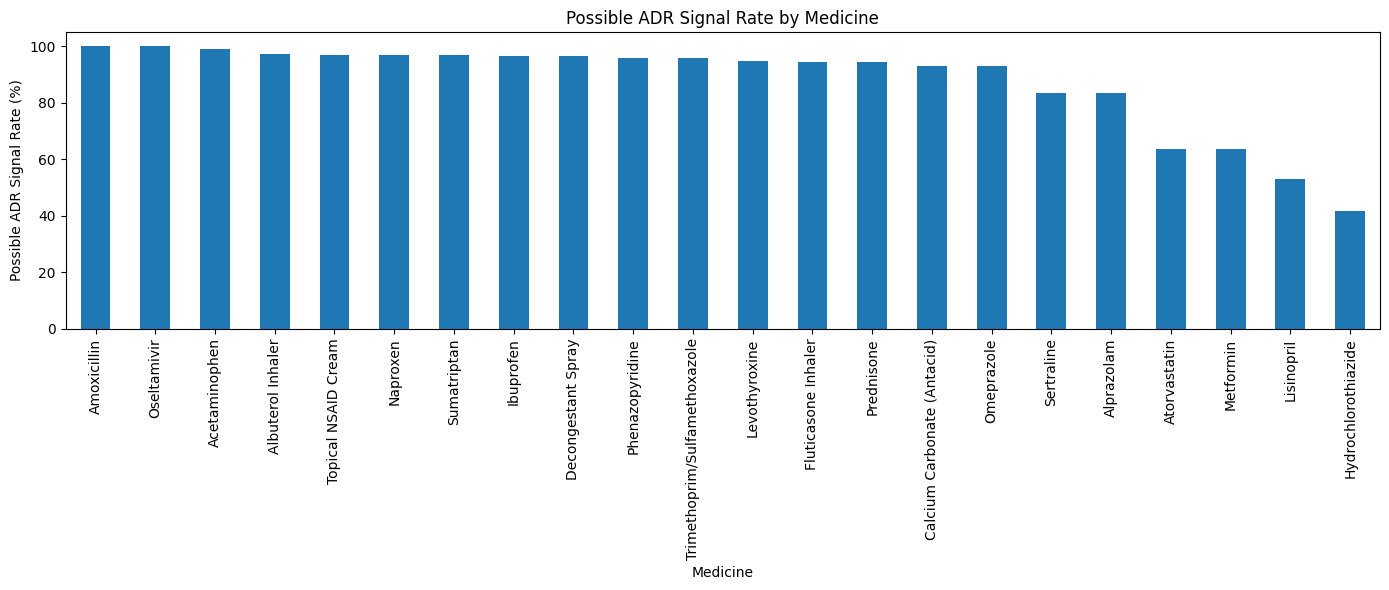

In [24]:
medicine_adr_summary['ADR_Signal_Rate_%'].plot(
    kind='bar',
    figsize=(14, 6),
    title='Possible ADR Signal Rate by Medicine'
)

plt.xlabel('Medicine')
plt.ylabel('Possible ADR Signal Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [23]:
import matplotlib.pyplot as plt

In [25]:
symptom_counts.sort_values(ascending=False)

,0
Has_Pain,7790
Has_Fatigue,7597
Has_Cough,4998
Has_Fever,3784


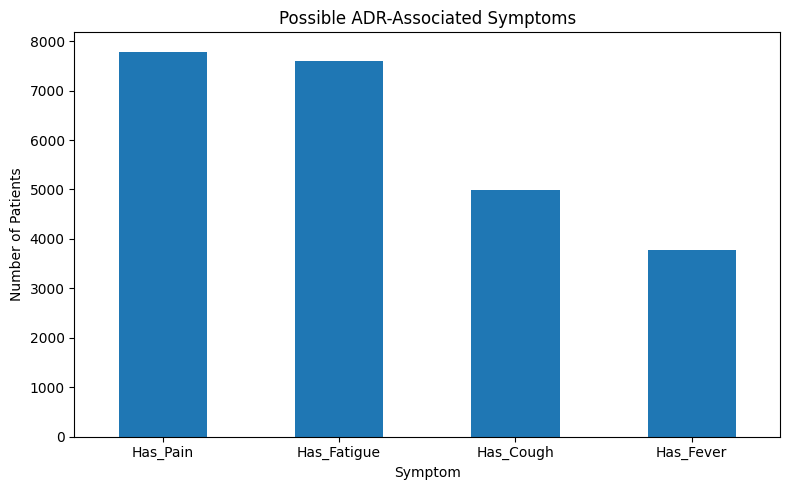

In [26]:
symptom_counts.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8, 5),
    title='Possible ADR-Associated Symptoms'
)

plt.xlabel('Symptom')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
disease_adr = df.groupby('Predicted_Disease')['Possible_ADR'].agg(
    Total_Patients='count',
    Possible_ADR_Signals=lambda x: (x > 0).sum()
)

disease_adr['ADR_Signal_Rate_%'] = (
    disease_adr['Possible_ADR_Signals']
    / disease_adr['Total_Patients']
    * 100
)

disease_adr.sort_values('ADR_Signal_Rate_%', ascending=False)

,Total_Patients,Possible_ADR_Signals,ADR_Signal_Rate_%
Predicted_Disease,,,
Bacterial Pneumonia,1179,1179,100.000000
Influenza,1182,1182,100.000000
Osteoarthritis,1132,1099,97.084806
Migraine,1092,1058,96.886447
Common Cold,1121,1083,96.610169
Urinary Tract Infection,1195,1145,95.815900
Hypothyroidism,1143,1085,94.925634
Asthma Exacerbation,1138,1075,94.463972
GERD,1174,1091,92.930153


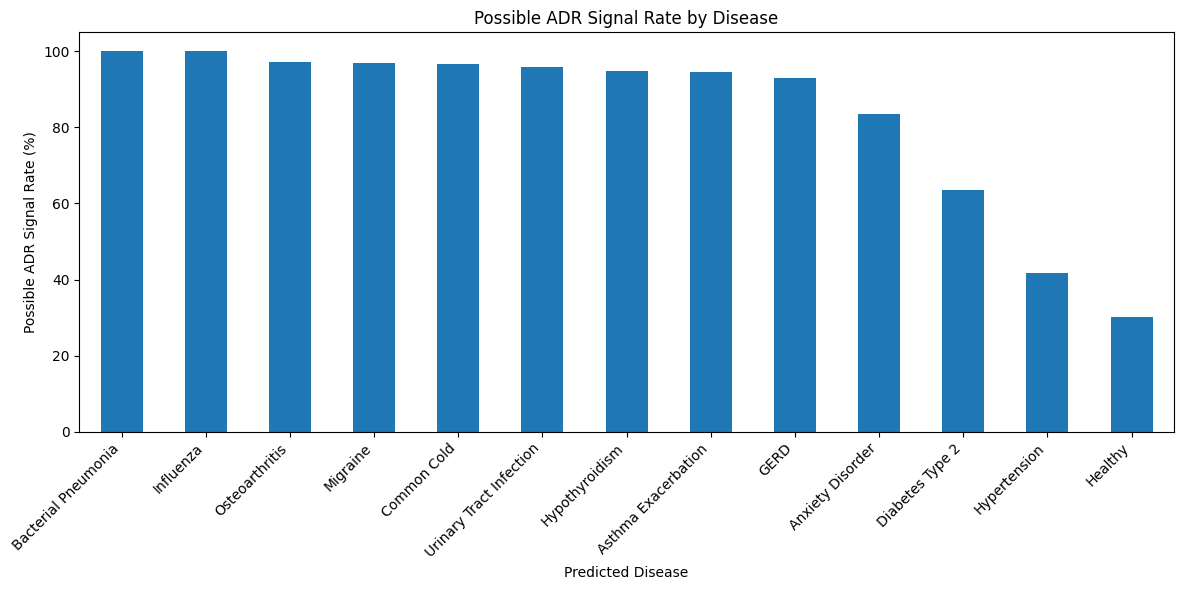

In [28]:
disease_adr['ADR_Signal_Rate_%'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12, 6),
    title='Possible ADR Signal Rate by Disease'
)

plt.xlabel('Predicted Disease')
plt.ylabel('Possible ADR Signal Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
df['Polypharmacy_Risk'].value_counts()

,count
Polypharmacy_Risk,
Medium,6956
Low,6849
High,1195


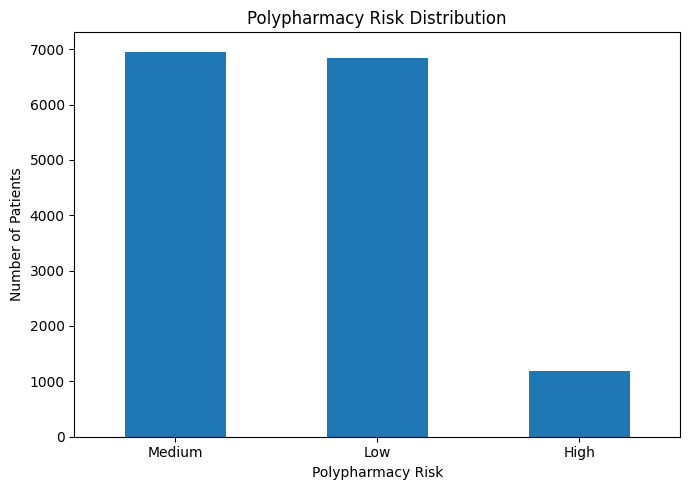

In [30]:
df['Polypharmacy_Risk'].value_counts().plot(
    kind='bar',
    figsize=(7, 5),
    title='Polypharmacy Risk Distribution'
)

plt.xlabel('Polypharmacy Risk')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
high_risk = df[df['Polypharmacy_Risk'] == 'High']

high_risk[['Medicine_1', 'Medicine_2', 'Medicine_3']].melt(
    value_name='Medicine'
)['Medicine'].value_counts()

,count
Medicine,
Metformin,1195
Atorvastatin,1195
Lisinopril,1195


In [32]:
poly_adr = df.groupby('Polypharmacy_Risk')['Possible_ADR'].agg(
    Total_Patients='count',
    Possible_ADR_Signals=lambda x: (x > 0).sum()
)

poly_adr['ADR_Signal_Rate_%'] = (
    poly_adr['Possible_ADR_Signals']
    / poly_adr['Total_Patients']
    * 100
)

poly_adr.sort_values('ADR_Signal_Rate_%', ascending=False)

,Total_Patients,Possible_ADR_Signals,ADR_Signal_Rate_%
Polypharmacy_Risk,,,
Medium,6956,5992,86.141461
Low,6849,5830,85.121916
High,1195,760,63.598326


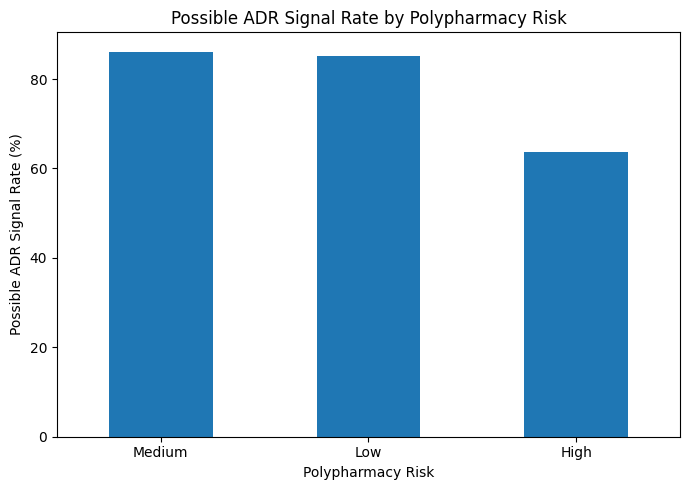

In [33]:
poly_adr['ADR_Signal_Rate_%'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(7, 5),
    title='Possible ADR Signal Rate by Polypharmacy Risk'
)

plt.xlabel('Polypharmacy Risk')
plt.ylabel('Possible ADR Signal Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
medicine_symptoms = medicine_long.merge(
    df[['Patient_ID', 'Has_Fever', 'Has_Cough', 'Has_Fatigue', 'Has_Pain']],
    on='Patient_ID',
    how='left'
)

medicine_symptom_rates = medicine_symptoms.groupby('Medicine')[
    ['Has_Fever', 'Has_Cough', 'Has_Fatigue', 'Has_Pain']
].mean() * 100

medicine_symptom_rates

,Has_Fever,Has_Cough,Has_Fatigue,Has_Pain
Medicine,,,,
Acetaminophen,61.809333,61.752076,65.817349,79.730890
Albuterol Inhaler,52.395339,90.461804,59.732413,45.835132
Alprazolam,3.846154,5.891980,68.494272,42.471358
Amoxicillin,90.585242,94.571671,76.675148,69.041561
Atorvastatin,4.602510,10.878661,49.456067,14.476987
Calcium Carbonate (Antacid),3.747871,32.879046,18.568995,85.264055
Decongestant Spray,40.945584,79.036574,58.429973,32.471008
Fluticasone Inhaler,12.829525,86.203866,42.179262,21.792619
Hydrochlorothiazide,4.374453,8.048994,23.359580,12.335958


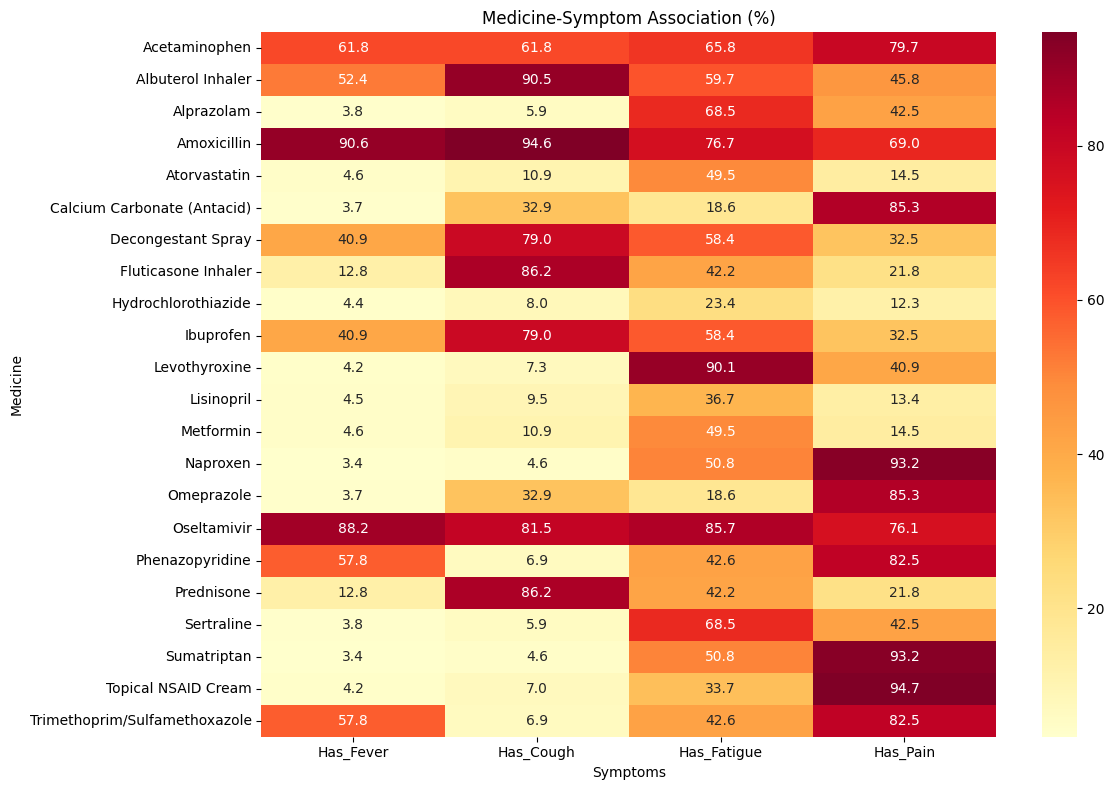

In [35]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    medicine_symptom_rates,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Medicine-Symptom Association (%)')
plt.xlabel('Symptoms')
plt.ylabel('Medicine')
plt.tight_layout()
plt.show()

In [36]:
medicine_symptom_rates.stack().sort_values(ascending=False).head(10)

,,0
Medicine,,
Topical NSAID Cream,Has_Pain,94.699647
Amoxicillin,Has_Cough,94.571671
Naproxen,Has_Pain,93.223443
Sumatriptan,Has_Pain,93.223443
Amoxicillin,Has_Fever,90.585242
Albuterol Inhaler,Has_Cough,90.461804
Levothyroxine,Has_Fatigue,90.113736
Oseltamivir,Has_Fever,88.240271
Prednisone,Has_Cough,86.203866


In [37]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Blood_Group,0
Weight_kg,0
Has_Fever,0
Has_Cough,0
Has_Fatigue,0
Has_Pain,0
Has_Hypertension,0


In [38]:
df['Patient_ID'].duplicated().sum()

np.int64(0)

In [39]:
df[['Age', 'Temperature_C', 'Heart_Rate', 'BP_Systolic', 'WBC_Count', 'Glucose_Level']].describe()

,Age,Temperature_C,Heart_Rate,BP_Systolic,WBC_Count,Glucose_Level
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,44.790667,37.247527,77.200533,122.353067,8.335633,102.394267
std,14.518383,0.852433,12.020697,13.022692,3.012926,30.088487
min,18.000000,34.900000,40.000000,72.000000,3.000000,60.000000
25%,35.000000,36.600000,68.000000,113.000000,6.300000,83.000000
50%,45.000000,37.100000,76.000000,121.000000,7.900000,98.000000
75%,55.000000,37.700000,86.000000,130.000000,9.800000,113.000000
max,90.000000,40.500000,119.000000,178.000000,21.400000,245.000000


In [40]:
medicine_adr_summary[['Total_Exposures', 'Possible_ADR_Signals', 'ADR_Signal_Rate_%']].head(10)

,Total_Exposures,Possible_ADR_Signals,ADR_Signal_Rate_%
Medicine,,,
Amoxicillin,1179,1179,100.000000
Oseltamivir,1182,1182,100.000000
Acetaminophen,3493,3460,99.055253
Albuterol Inhaler,2317,2254,97.280967
Topical NSAID Cream,1132,1099,97.084806
Naproxen,1092,1058,96.886447
Sumatriptan,1092,1058,96.886447
Ibuprofen,1121,1083,96.610169
Decongestant Spray,1121,1083,96.610169


In [41]:
df.to_csv(
    '/content/Task4_Adverse_Drug_Reaction_Analysis.csv',
    index=False
)

print("Task 4 analysis dataset saved successfully.")

Task 4 analysis dataset saved successfully.


## Task 4: Adverse Drug Reaction Analysis — Summary

- Analyzed 15,000 synthetic patient records.
- Checked data quality, missing values, and duplicate patient IDs.
- Created a Possible_ADR signal using fever, cough, fatigue, and pain indicators.
- Analyzed possible ADR signal rates across medicines and diseases.
- Examined medicine-symptom associations using a heatmap.
- Analyzed polypharmacy risk and its relationship with possible ADR signals.
- Identified medicines with higher possible ADR signal rates for further review.
- These are possible safety signals, not confirmed adverse drug reactions, because the dataset does not contain confirmed ADR outcomes or reaction timelines.